<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/Test_Grab_Transbport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color='red'>**25.07.2026 10pm**

#**Chapter 1. Setup and load libraries**

In [4]:
# Core Libraries
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries and preprocessing
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42

print('Setup complete')

Setup complete


#**Chapter 2: Upload and Read Dataset**

In [5]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub fileynth
github_raw_url = 'https://raw.githubusercontent.com/miffylim2308/ADALL_github/refs/heads/main/synthetic_grab_transport_v3_5000_23pct_cancel.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")


Successfully loaded data from GitHub!


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026004274,2026-02-09 00:02:29,0,Monday,2,0,0,1,0,Sentosa,...,Medium,1.00,0,1,2,22.65,One version behind,Good,0,Not Cancelled
1,BK2026004453,2026-02-10 13:54:27,13,Tuesday,2,0,0,0,0,Orchard,...,Medium,1.00,0,0,0,17.92,Current,Average,0,Not Cancelled
2,BK2026014098,2026-05-08 03:10:44,3,Friday,5,0,0,1,0,Bukit Timah,...,Medium,1.10,0,1,5,8.22,One version behind,Average,0,Not Cancelled
3,BK2026016317,2026-05-27 18:22:45,18,Wednesday,5,0,1,0,1,Changi,...,Severe,1.50,0,0,0,28.83,One version behind,Good,1,Found alternative transport
4,BK2026012840,2026-04-26 17:36:56,17,Sunday,4,1,1,0,0,Queenstown,...,Severe,1.29,0,0,0,23.22,Current,Good,1,Fare too high


#**Chapter 3. Set up OpenAI**

In [7]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


#**Chapter 4:Quick dataset inspection before using an LLM**

In [13]:
print('Shape:', df.shape)

display(df.head())

print('\nInfo:')
display(df.info())

print('\nColumns:', df.columns.tolist())

print("\nDescribe:")
display(df.describe(include='all').transpose())

missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

duplicate_count = df.duplicated().sum()
print("\nDuplicate count:", duplicate_count)

Shape: (5000, 50)


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026004274,2026-02-09 00:02:29,0,Monday,2,0,0,1,0,Sentosa,...,Medium,1.00,0,1,2,22.65,One version behind,Good,0,Not Cancelled
1,BK2026004453,2026-02-10 13:54:27,13,Tuesday,2,0,0,0,0,Orchard,...,Medium,1.00,0,0,0,17.92,Current,Average,0,Not Cancelled
2,BK2026014098,2026-05-08 03:10:44,3,Friday,5,0,0,1,0,Bukit Timah,...,Medium,1.10,0,1,5,8.22,One version behind,Average,0,Not Cancelled
3,BK2026016317,2026-05-27 18:22:45,18,Wednesday,5,0,1,0,1,Changi,...,Severe,1.50,0,0,0,28.83,One version behind,Good,1,Found alternative transport
4,BK2026012840,2026-04-26 17:36:56,17,Sunday,4,1,1,0,0,Queenstown,...,Severe,1.29,0,0,0,23.22,Current,Good,1,Fare too high



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 50 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   booking_id                       5000 non-null   object 
 1   booking_datetime                 5000 non-null   object 
 2   booking_hour                     5000 non-null   int64  
 3   day_of_week                      5000 non-null   object 
 4   month                            5000 non-null   int64  
 5   is_weekend                       5000 non-null   int64  
 6   is_peak_hour                     5000 non-null   int64  
 7   is_late_night                    5000 non-null   int64  
 8   public_holiday                   5000 non-null   int64  
 9   pickup_zone                      5000 non-null   object 
 10  pickup_zone_type                 5000 non-null   object 
 11  dropoff_zone                     5000 non-null   object 
 12  dropoff_zone_

None


Columns: ['booking_id', 'booking_datetime', 'booking_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone', 'dropoff_zone_type', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'vehicle_type', 'payment_method', 'customer_segment', 'loyalty_tier', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'eta_change_min', 'weather', 'is_raining', 'traffic_level', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd', 'app_version', 'network_quality', 'customer_cancelled'

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,5000,5000,BK2026007766,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_datetime,5000,4998,2026-03-16 17:02:07,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_hour,5000.0,NaN,NaN,NaN,11.6984,6.833914,0.0,6.0,12.0,18.0,23.0
day_of_week,5000,7,Sunday,763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,5000.0,NaN,NaN,NaN,3.49,1.68857,1.0,2.0,3.0,5.0,6.0
is_weekend,5000.0,NaN,NaN,NaN,0.2916,0.454545,0.0,0.0,0.0,1.0,1.0
is_peak_hour,5000.0,NaN,NaN,NaN,0.3084,0.461879,0.0,0.0,0.0,1.0,1.0
is_late_night,5000.0,NaN,NaN,NaN,0.276,0.447061,0.0,0.0,0.0,1.0,1.0
public_holiday,5000.0,NaN,NaN,NaN,0.0324,0.177078,0.0,0.0,0.0,0.0,1.0
pickup_zone,5000,15,CBD,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values:
 booking_id                            0
booking_datetime                      0
booking_hour                          0
day_of_week                           0
month                                 0
is_weekend                            0
is_peak_hour                          0
is_late_night                         0
public_holiday                        0
pickup_zone                           0
pickup_zone_type                      0
dropoff_zone                          0
dropoff_zone_type                     0
airport_trip                          0
cbd_trip                              0
distance_km                           0
estimated_trip_duration_min           0
vehicle_type                          0
payment_method                        0
customer_segment                      0
loyalty_tier                       1659
customer_tenure_days                  0
rides_last_7_days                     0
rides_last_30_days                    0
customer_cancel_rate_90

In [12]:
# PROMPT - LLM-assisted problem framing

prompt_framing = f"""
You are an experienced data scientist specialising in machine learning for business problems.

Your task is to translate the following business problem into a machine learning modelling objective.
=======================
DATASET PREVIEW
=======================
{df.head()}

=========================
BUSINESS CONTEXT
=========================
Business Problem:
Grab Ride Operations Manager has observed a high rate of customer cancellations before the trip commencement over the past few months.

Business Objective:
Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.

Business Goal:
Reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.

Dataset Context:
The dataset contains synthetic ride-hailing booking data.
Each row represents one booking made by a customer.
The dataset includes customer information, booking details, driver availability, pricing, weather, traffic conditions, and booking outcomes.

=========================
TASK
=========================
Answer the following questions:

1. What should the machine learning modelling objective be?

2. Which column should be used as the target variable? Explain why.

3. Which evaluation metric(s) would you recommend for this classification problem?
Explain why these metrics would be meaningful and easy for business stakeholders to understand.

4. Who are the main business stakeholders that would use the model?

5. Identify three potential risks or pitfalls when developing or deploying this model.

=========================
IMPORTANT
=========================
Use ONLY the information provided in the business context and dataset profile.
Do NOT invent columns, business processes or stakeholders that are not supported by the information provided.
If an answer requires assumptions, clearly label them as "Assumption".
If information is not available, state the assumptions you are making.
Present your answers using clear headings and concise explanations suitable for a university report.
"""
print('=== Prompt to send ===')
print(prompt_framing[:2000])


response_framing = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_framing
)
print('\n=== LLM response ===')
print(response_framing.output_text)



=== Prompt to send ===

You are an experienced data scientist specialising in machine learning for business problems.

Your task is to translate the following business problem into a machine learning modelling objective.
DATASET PREVIEW
     booking_id     booking_datetime  booking_hour day_of_week  month  \
0  BK2026004274  2026-02-09 00:02:29             0      Monday      2   
1  BK2026004453  2026-02-10 13:54:27            13     Tuesday      2   
2  BK2026014098  2026-05-08 03:10:44             3      Friday      5   
3  BK2026016317  2026-05-27 18:22:45            18   Wednesday      5   
4  BK2026012840  2026-04-26 17:36:56            17      Sunday      4   

   is_weekend  is_peak_hour  is_late_night  public_holiday  pickup_zone  ...  \
0           0             0              1               0      Sentosa  ...   
1           0             0              0               0      Orchard  ...   
2           0             0              1               0  Bukit Timah  ...   
3   

#**Section 2: Define Target and Remove Leakage Columns**

In [3]:
target = "customer_cancelled"

drop_cols = [
    "booking_id",
    "booking_datetime",
    "cancel_reason"   # leakage: only known after cancellation
]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

print(X.shape)
print(y.value_counts(normalize=True))

(5000, 46)
customer_cancelled
0    0.77
1    0.23
Name: proportion, dtype: float64


#**Section 3: Correlation for Numeric Variables**

In [ ]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

corr_df = df[numeric_cols.tolist() + [target]].corr()[target] \
    .drop(target) \
    .sort_values(key=abs, ascending=False) \
    .reset_index()

corr_df.columns = ["Feature", "Correlation with customer_cancelled"]

corr_df.head(15)

,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.697512
1,driver_eta_min,0.641218
2,is_peak_hour,0.567279
3,supply_demand_ratio,-0.542120
4,drivers_declined_before_accept,0.523173
5,driver_distance_to_pickup_km,0.480110
6,booking_demand_zone,0.469453
7,active_driver_supply_zone,-0.441864
8,driver_acceptance_time_sec,0.369772
9,estimated_fare_sgd,0.336150


#**Section 4. Prepare data for machine learning**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

#**Section 5. Logistic Regression coefficients**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
import numpy as np

feature_names = log_model.named_steps["preprocess"].get_feature_names_out()
coefficients = log_model.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values("Abs_Coefficient", ascending=False)

log_coef_df.head(60)

,Feature,Coefficient,Abs_Coefficient
25,num__driver_eta_min,3.251682,3.251682
28,num__surge_multiplier,1.882079,1.882079
96,cat__customer_segment_New,1.623277,1.623277
95,cat__customer_segment_High Value,-1.277430,1.277430
26,num__eta_change_min,1.233861,1.233861
22,num__drivers_declined_before_accept,1.204328,1.204328
110,cat__traffic_level_Severe,0.912459,0.912459
98,cat__customer_segment_Regular,-0.884189,0.884189
30,num__promo_applied,-0.855485,0.855485
8,num__distance_km,0.732039,0.732039


#**Section 6. Random Forest feature importance**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

#**Section 7. SHAP values**

In [ ]:
!pip install shap -q

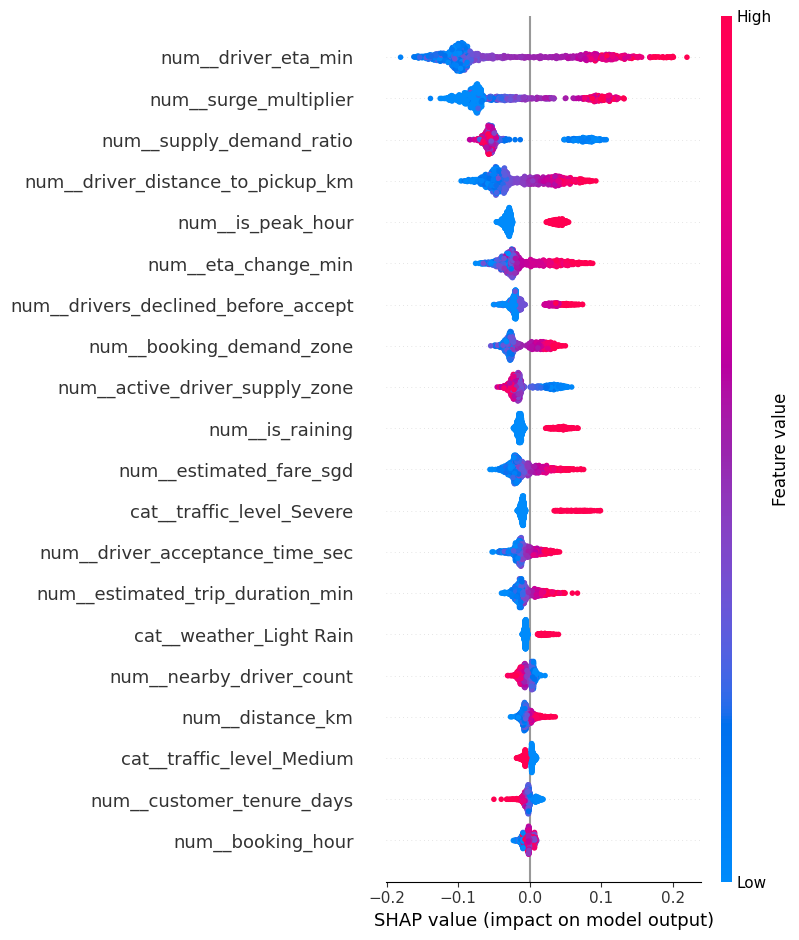

In [ ]:
import shap

# Transform training and test data
X_train_transformed = rf_model.named_steps["preprocess"].transform(X_train)
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)

# Convert sparse matrix to dense if needed
X_test_dense = X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed
import shap

# Transform test data
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)

# Convert sparse matrix to dense if needed
X_test_dense = (
    X_test_transformed.toarray()
    if hasattr(X_test_transformed, "toarray")
    else X_test_transformed
)

# Get transformed feature names
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Use a sample
sample_size = 1000
X_shap = X_test_dense[:sample_size]

# Convert X_shap back to DataFrame with feature names
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

# SHAP
explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

# For binary classification: class 1 = customer cancelled
shap_cancelled = shap_values[:, :, 1]

shap.summary_plot(
    shap_cancelled,
    X_shap_df
)
# Use a sample to keep SHAP fast
sample_size = 1000
X_shap = X_test_dense[:sample_size]

explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

In [ ]:
#Checking the shape of shap values
print("X_shap shape:", X_shap.shape)
print("Type of shap_values:", type(shap_values))

if isinstance(shap_values, list):
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)
else:
    print("shap_values shape:", shap_values.shape)
print(type(X_shap))
print(type(X_shap_df))
print(X_shap.shape)
print(X_shap_df.shape)

X_shap shape: (1000, 117)
Type of shap_values: <class 'numpy.ndarray'>
shap_values shape: (1000, 117, 2)
<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
(1000, 117)
(1000, 117)


In [ ]:
print("rf_importance_df" in globals())

False


#**Section 8. Create final comparison table**

In [ ]:
import pandas as pd

# Get transformed feature names after preprocessing
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Get Random Forest feature importances
rf_importances = rf_model.named_steps["model"].feature_importances_

# Create DataFrame
rf_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "RF_Importance": rf_importances
    })
    .sort_values("RF_Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance_df.head(15))

,Feature,RF_Importance
0,num__driver_eta_min,0.162169
1,num__surge_multiplier,0.129832
2,num__supply_demand_ratio,0.111362
3,num__driver_distance_to_pickup_km,0.067158
4,num__is_peak_hour,0.060520
5,num__active_driver_supply_zone,0.053290
6,num__booking_demand_zone,0.045229
7,num__eta_change_min,0.037788
8,num__drivers_declined_before_accept,0.036647
9,num__estimated_fare_sgd,0.025876


In [ ]:
top_corr = corr_df.head(15)
top_log = log_coef_df.head(15)
top_rf = rf_importance_df.head(15)

print("Top Numeric Correlations")
display(top_corr)

print("Top Logistic Regression Coefficients")
display(top_log)

print("Top Random Forest Importances")
display(top_rf)

Top Numeric Correlations


,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.697512
1,driver_eta_min,0.641218
2,is_peak_hour,0.567279
3,supply_demand_ratio,-0.542120
4,drivers_declined_before_accept,0.523173
5,driver_distance_to_pickup_km,0.480110
6,booking_demand_zone,0.469453
7,active_driver_supply_zone,-0.441864
8,driver_acceptance_time_sec,0.369772
9,estimated_fare_sgd,0.336150


Top Logistic Regression Coefficients


,Feature,Coefficient,Abs_Coefficient
25,num__driver_eta_min,3.251682,3.251682
28,num__surge_multiplier,1.882079,1.882079
96,cat__customer_segment_New,1.623277,1.623277
95,cat__customer_segment_High Value,-1.277430,1.277430
26,num__eta_change_min,1.233861,1.233861
22,num__drivers_declined_before_accept,1.204328,1.204328
110,cat__traffic_level_Severe,0.912459,0.912459
98,cat__customer_segment_Regular,-0.884189,0.884189
30,num__promo_applied,-0.855485,0.855485
8,num__distance_km,0.732039,0.732039


Top Random Forest Importances


,Feature,RF_Importance
0,num__driver_eta_min,0.162169
1,num__surge_multiplier,0.129832
2,num__supply_demand_ratio,0.111362
3,num__driver_distance_to_pickup_km,0.067158
4,num__is_peak_hour,0.060520
5,num__active_driver_supply_zone,0.053290
6,num__booking_demand_zone,0.045229
7,num__eta_change_min,0.037788
8,num__drivers_declined_before_accept,0.036647
9,num__estimated_fare_sgd,0.025876


## **Section 9. Evaluate Model Performance**

In [ ]:
from sklearn.metrics import classification_report

# Evaluate Logistic Regression Model
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1540
           1       0.83      0.94      0.88       460

    accuracy                           0.94      2000
   macro avg       0.91      0.94      0.92      2000
weighted avg       0.95      0.94      0.94      2000



In [ ]:
# Evaluate Random Forest Model
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1540
           1       0.87      0.85      0.86       460

    accuracy                           0.94      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.93      0.94      0.93      2000

